Step 1: download data 

In [ ]:
#ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased (just for me to remember the name of the downlaoded file)

step 2: install plink

In [4]:
# First, find where plink is installed
!which plink

/opt/anaconda3/envs/popgen/bin/plink


In [9]:
!cat chr1_raw.log

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)
Options in effect:
  --biallelic-only strict
  --double-id
  --make-bed
  --out chr1_raw
  --vcf ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz
  --vcf-half-call missing

Hostname: MacBook-Air-von-Nami.local
Working directory: /Users/namiaston/bioinformatikblockkurs
Start time: Wed Apr 29 10:10:17 2026

Random number seed: 1777450217
8192 MB RAM detected; reserving 4096 MB for main workspace.
Error: Failed to open
ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz. (--vcf expects
a complete filename; did you forget '.vcf' at the end?)

End time: Wed Apr 29 10:10:17 2026


In [ ]:

!plink \
  --vcf ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf \
  --make-bed \
  --out chr1_raw \
  --double-id \
  --vcf-half-call missing \
  --biallelic-only strict

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_raw.log.
Options in effect:
  --biallelic-only strict
  --double-id
  --make-bed
  --out chr1_raw
  --vcf ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf
  --vcf-half-call missing

8192 MB RAM detected; reserving 4096 MB for main workspace.

Error: Line 25 of .vcf file has fewer tokens than expected.


In [16]:
!curl -L -C - -O https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000_genomes_project/release/20181203_biallelic_SNV/ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  902M  100  902M    0     0  18.6M      0  0:00:48  0:00:48 --:--:-- 17.4M9.8M      0  0:00:45  0:00:03  0:00:42 19.8M98M    0     0  19.8M      0  0:00:45  0:00:09  0:00:36 20.1M   0     0  18.9M      0  0:00:47  0:00:39  0:00:08 18.2M


In [17]:
!ls -lh ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz

-rw-r--r--@ 1 namiaston  staff   902M Apr 29 10:21 ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz


In [20]:
!bgzip -t ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz
# No output = good

In [19]:
!conda install -c bioconda htslib -y

2 channel Terms of Service accepted
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /opt/anaconda3/envs/popgen

  added / updated specs:
    - htslib


The following NEW packages will be INSTALLED:

  c-ares             conda-forge/osx-arm64::c-ares-1.34.6-hc919400_0 
  htslib             bioconda/osx-arm64::htslib-1.23.1-h44a9eb5_0 
  libcurl            conda-forge/osx-arm64::libcurl-8.19.0-hd5a2499_0 
  libev              conda-forge/osx-arm64::libev-4.33-h93a5062_2 
  libnghttp2         conda-forge/osx-arm64::libnghttp2-1.68.1-h8f3e76b_0 
  libssh2            conda-forge/osx-arm64::libssh2-1.11.1-h1590b86_0 




Preparing transaction: done
Verifying transaction: done
Executing transaction: done


In [21]:
!plink \
  --vcf ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz \
  --make-bed \
  --out chr1_raw \
  --double-id \
  --vcf-half-call missing \
  --biallelic-only strict

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_raw.log.
Options in effect:
  --biallelic-only strict
  --double-id
  --make-bed
  --out chr1_raw
  --vcf ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz
  --vcf-half-call missing

8192 MB RAM detected; reserving 4096 MB for main workspace.
--vcf: chr1_raw-temporary.bed + chr1_raw-temporary.bim + chr1_raw-temporary.fam
written.
5795045 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_raw.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081828384858687888990919293

output shows: 5,795,045 SNPs loaded from chr1
2,548 individuals from the 1000 Genomes project
100% genotyping rate — no missing data, clean file

In [22]:
!plink \
  --bfile chr1_raw \
  --maf 0.05 \
  --geno 0.05 \
  --mind 0.1 \
  --hwe 1e-6 \
  --make-bed \
  --out chr1_qc

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_qc.log.
Options in effect:
  --bfile chr1_raw
  --geno 0.05
  --hwe 1e-6
  --maf 0.05
  --make-bed
  --mind 0.1
  --out chr1_qc

8192 MB RAM detected; reserving 4096 MB for main workspace.
5795045 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_qc.nosex .
0 people removed due to missing genotype data (--mind).
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
0 variants removed due to missing genotype data

In [ ]:

!plink \
  --bfile chr1_qc \
  --indep-pairwise 50 10 0.1 \
  --out chr1_prune

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_prune.log.
Options in effect:
  --bfile chr1_qc
  --indep-pairwise 50 10 0.1
  --out chr1_prune

8192 MB RAM detected; reserving 4096 MB for main workspace.
333378 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_prune.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
333378 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Pruned 316146 variants from chromosome 1, leaving 1

In [ ]:

!plink \
  --bfile chr1_qc \
  --extract chr1_prune.prune.in \
  --make-bed \
  --out chr1_pruned

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_pruned.log.
Options in effect:
  --bfile chr1_qc
  --extract chr1_prune.prune.in
  --make-bed
  --out chr1_pruned

8192 MB RAM detected; reserving 4096 MB for main workspace.
333378 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_pruned.nosex .
--extract: 333378 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
333378 variants and 2548 people pass filters and QC.
Note: No phenotypes pre

In [ ]:

!sort -u chr1_prune.prune.in > chr1_prune_unique.in


!wc -l chr1_prune_unique.in

       1 chr1_prune_unique.in


In [26]:
!plink \
  --bfile chr1_qc \
  --extract chr1_prune_unique.in \
  --make-bed \
  --out chr1_pruned

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_pruned.log.
Options in effect:
  --bfile chr1_qc
  --extract chr1_prune_unique.in
  --make-bed
  --out chr1_pruned

8192 MB RAM detected; reserving 4096 MB for main workspace.
333378 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_pruned.nosex .
--extract: 333378 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
333378 variants and 2548 people pass filters and QC.
Note: No phenotypes pr

In [ ]:

!head -5 chr1_prune.prune.in


!head -5 chr1_qc.bim

.
.
.
.
.
1	.	0	51479	A	T
1	.	0	54490	A	G
1	.	0	54708	C	G
1	.	0	54716	T	C
1	.	0	54753	G	T


In [ ]:

!plink \
  --bfile chr1_qc \
  --set-missing-var-ids @:# \
  --make-bed \
  --out chr1_qc_ids

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_qc_ids.log.
Options in effect:
  --bfile chr1_qc
  --make-bed
  --out chr1_qc_ids
  --set-missing-var-ids @:#

8192 MB RAM detected; reserving 4096 MB for main workspace.
333378 variants loaded from .bim file.
333378 missing IDs set.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_qc_ids.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
333378 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
--make-bed t

In [29]:
# Redo pruning with proper IDs
!plink \
  --bfile chr1_qc_ids \
  --indep-pairwise 50 10 0.1 \
  --out chr1_prune

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_prune.log.
Options in effect:
  --bfile chr1_qc_ids
  --indep-pairwise 50 10 0.1
  --out chr1_prune

8192 MB RAM detected; reserving 4096 MB for main workspace.
333378 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_prune.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
333378 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Pruned 316146 variants from chromosome 1, leavi

In [30]:
# Extract pruned SNPs
!plink \
  --bfile chr1_qc_ids \
  --extract chr1_prune.prune.in \
  --make-bed \
  --out chr1_pruned

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_pruned.log.
Options in effect:
  --bfile chr1_qc_ids
  --extract chr1_prune.prune.in
  --make-bed
  --out chr1_pruned

8192 MB RAM detected; reserving 4096 MB for main workspace.
333378 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_pruned.nosex .
--extract: 17232 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
17232 variants and 2548 people pass filters and QC.
Note: No phenotypes p

now run the pca

In [31]:
!plink \
  --bfile chr1_pruned \
  --pca 20 \
  --out chr1_pca

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_pca.log.
Options in effect:
  --bfile chr1_pruned
  --out chr1_pca
  --pca 20

8192 MB RAM detected; reserving 4096 MB for main workspace.
17232 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_pca.nosex .
Using up to 8 threads (change this with --threads).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
17232 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Relationship matrix calculation complete.
--pca: Results saved to chr1_pca.ei

In [32]:
!curl -L -O https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.panel

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 55156  100 55156    0     0   386k      0 --:--:-- --:--:-- --:--:--  387k


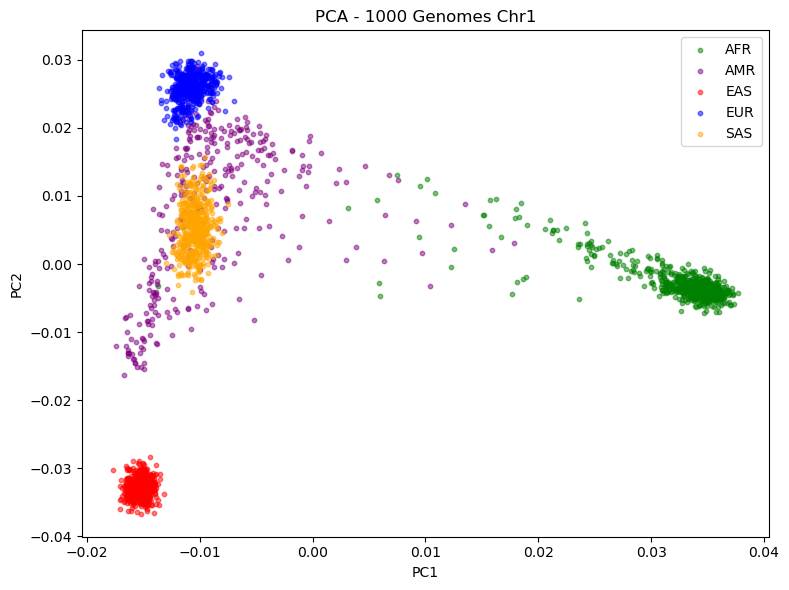

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load PCA results
pca = pd.read_csv("chr1_pca.eigenvec", sep="\s+", header=None)
pca.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, 21)]

# Load population labels
pop = pd.read_csv("integrated_call_samples_v3.20130502.ALL.panel", sep="\t")

# Merge
pca = pca.merge(pop[["sample", "super_pop"]], left_on="IID", right_on="sample")

# Plot PC1 vs PC2
fig, ax = plt.subplots(figsize=(8, 6))
colors = {"EUR": "blue", "AFR": "green", "EAS": "red", "SAS": "orange", "AMR": "purple"}

for grp, df in pca.groupby("super_pop"):
    ax.scatter(df.PC1, df.PC2, label=grp, alpha=0.5, s=10, color=colors[grp])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA - 1000 Genomes Chr1")
ax.legend()
plt.tight_layout()
plt.savefig("pca_plot.png", dpi=150)
plt.show()

In [36]:
!conda install -c bioconda admixture -y

2 channel Terms of Service accepted
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: failed

PackagesNotFoundError: The following packages are not available from current channels:

  - admixture

Current channels:

  - https://conda.anaconda.org/bioconda
  - https://conda.anaconda.org/conda-forge
  - defaults

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




In [39]:
!curl -L -O https://dalexander.github.io/admixture/binaries/admixture_macosx-1.3.0.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1626k  100 1626k    0     0  3514k      0 --:--:-- --:--:-- --:--:-- 3513k


In [40]:
!tar -xzf admixture_macosx-1.3.0.tar.gz

In [45]:
!ls admixture*

admixture_macosx-1.3.0.tar.gz


In [43]:
!tar -xvzf admixture_macosx-1.3.0.tar.gz

x dist/admixture_macosx-1.3.0/
x dist/admixture_macosx-1.3.0/README.32.txt
x dist/admixture_macosx-1.3.0/admixture
x dist/admixture_macosx-1.3.0/admixture32
x dist/admixture_macosx-1.3.0/admixture-manual.pdf


In [44]:
!dist/admixture_macosx-1.3.0/admixture | head -3

****                   ADMIXTURE Version 1.3.0                  ****
Usage: admixture <input file> <K>
See --help or manual for more advanced usage.
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****


In [47]:
import subprocess, re

for k in range(2, 6):
    print(f"Running ADMIXTURE K={k}...")
    result = subprocess.run(
        ["dist/admixture_macosx-1.3.0/admixture", "--cv", "chr1_pruned.bed", str(k)],
        capture_output=True, text=True
    )
    print(result.stdout)
    with open(f"admixture_K{k}.log", "w") as f:
        f.write(result.stdout)

print("All done!")

Running ADMIXTURE K=2...
****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Cross-validation will be performed.  Folds=5.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x17232
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 21.813	Loglikelihood: -4.29381e+07	(delta): 3.21164e+07
2 (EM) 	Elapsed: 2

KeyboardInterrupt: 

In [48]:
!ls -lh *.Q

-rw-r--r--@ 1 namiaston  staff    45K Apr 29 11:34 chr1_pruned.2.Q
-rw-r--r--@ 1 namiaston  staff    67K Apr 29 12:09 chr1_pruned.3.Q
-rw-r--r--@ 1 namiaston  staff    90K Apr 29 13:14 chr1_pruned.4.Q


In [50]:
import subprocess

result = subprocess.run(
    ["dist/admixture_macosx-1.3.0/admixture", "-j8", "chr1_pruned.bed", "5"],
    capture_output=True, text=True
)
print(result.stdout)
with open("admixture_K5.log", "w") as f:
    f.write(result.stdout)

print("Done!")

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 8 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x17232
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 20.793	Loglikelihood: -4.33901e+07	(delta): 2.34714e+07
2 (EM) 	Elapsed: 20.454	Loglikelihood:

In [51]:
!ls *.Q

chr1_pruned.2.Q chr1_pruned.3.Q chr1_pruned.4.Q chr1_pruned.5.Q


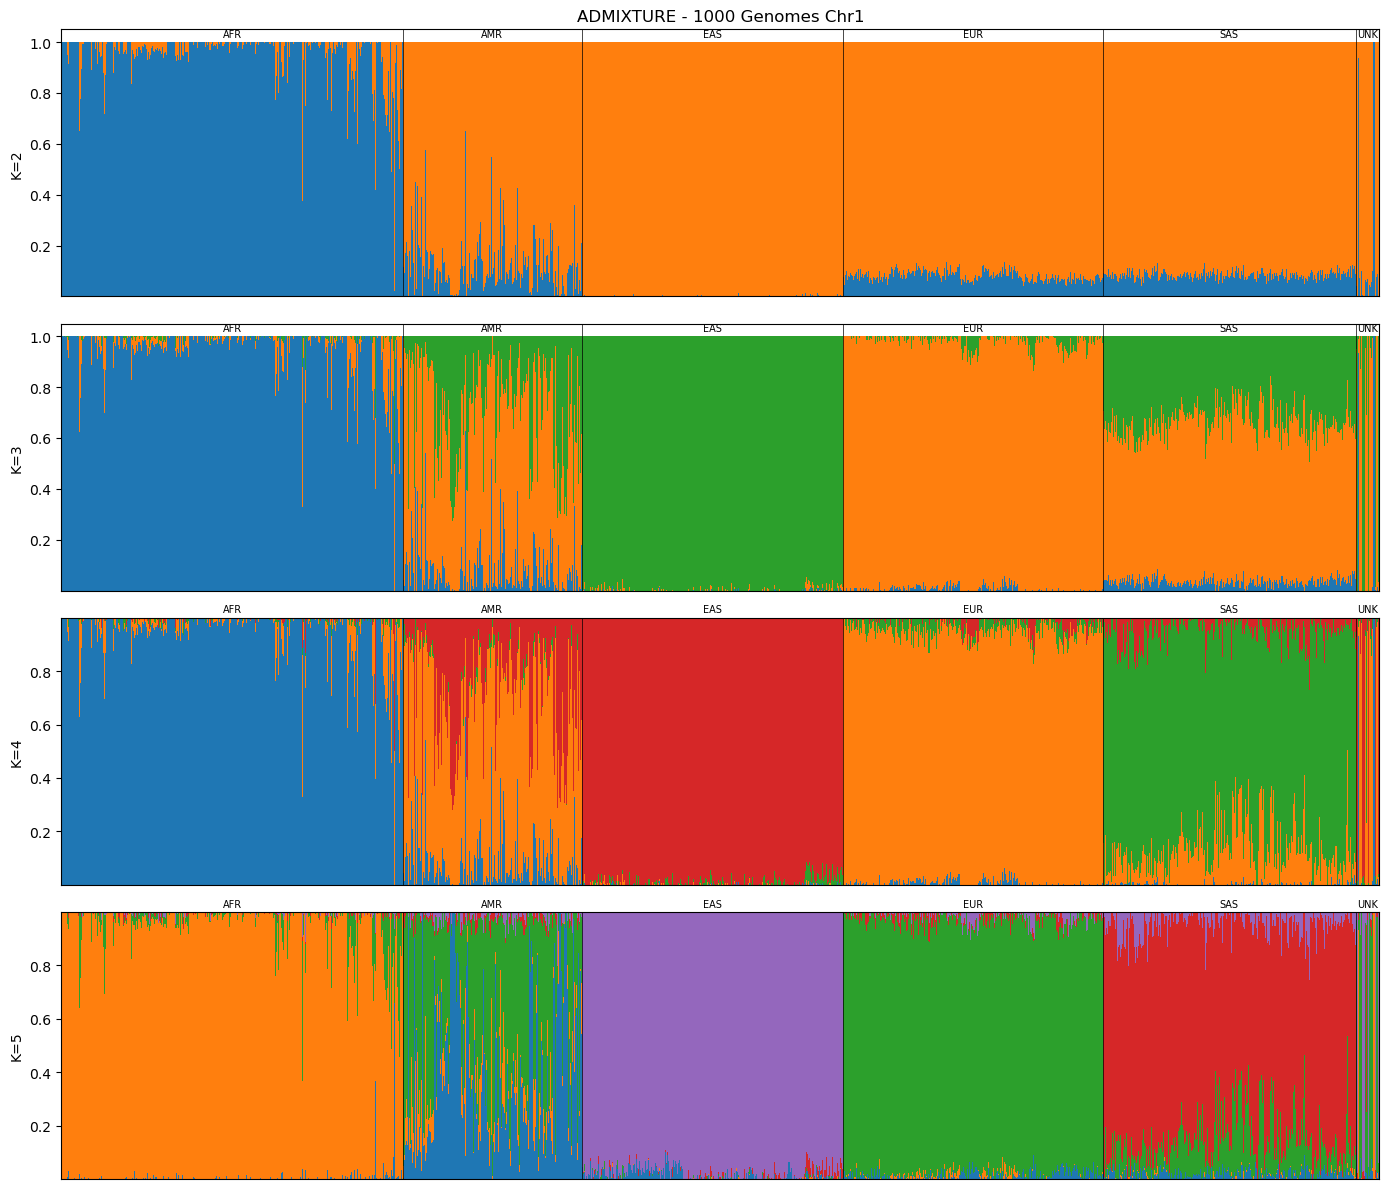

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load population labels
pop = pd.read_csv("integrated_call_samples_v3.20130502.ALL.panel", sep="\s+")
fam = pd.read_csv("chr1_pruned.fam", sep="\s+", header=None)
fam.columns = ["FID", "IID", "PAT", "MAT", "SEX", "PHENO"]

# Merge and reset index
fam = fam.merge(pop[["sample", "super_pop"]], left_on="IID", right_on="sample", how="left")
fam["super_pop"] = fam["super_pop"].fillna("UNK")
fam = fam.reset_index(drop=True)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

for idx, k in enumerate([2, 3, 4, 5]):
    Q = pd.read_csv(f"chr1_pruned.{k}.Q", sep="\s+", header=None)
    Q["super_pop"] = fam["super_pop"].values
    Q = Q.sort_values("super_pop").reset_index(drop=True)
    
    ax = axes[idx]
    bottom = np.zeros(len(Q))
    for col in range(k):
        ax.bar(range(len(Q)), Q[col], bottom=bottom, width=1, linewidth=0)
        bottom += Q[col].values
    
    ax.set_ylabel(f"K={k}")
    ax.set_xlim(0, len(Q))
    ax.set_xticks([])

    # Population boundary labels
    prev = 0
    for spop, grp in Q.groupby("super_pop"):
        mid = prev + len(grp) // 2
        ax.text(mid, 1.02, spop, fontsize=7, ha="center")
        ax.axvline(prev, color="black", linewidth=0.5)
        prev += len(grp)

axes[0].set_title("ADMIXTURE - 1000 Genomes Chr1")
plt.tight_layout()
plt.savefig("admixture_plot.png", dpi=150)
plt.show()



ADMIXTURE models each individual's genome as a mixture of K ancestral 
populations. Higher K values allow finer resolution of population structure.

**K=2:** The analysis separates African (AFR) from non-African populations. 
This reflects the major split in human evolutionary history, the Out-of-Africa 
migration, and is consistently the first axis of genetic differentiation seen 
in global datasets.

**K=3:** A third ancestral component emerges, separating East Asian (EAS) from 
European (EUR) populations. At this level we can distinguish three broad 
continental groups: African, European, and East/South Asian.

**K=4:** South Asian (SAS) individuals begin to separate as a distinct component, 
reflecting their unique ancestry history with contributions from both West Eurasian 
and East Asian populations.

**K=5:** The fifth component separates American (AMR) populations. AMR individuals 
show mixed ancestry proportions , drawing from European, African, and Native American 
components, consistent with the known admixed history of these populations due to 
colonization and the transatlantic slave trade.

**Individual composition:** Most African, East Asian, and European individuals show 
near-homogeneous ancestry (>90% from one component), reflecting relatively little 
recent admixture. In contrast, AMR individuals consistently show mixed proportions 
across multiple components, making them the most admixed group in the dataset. 
This pattern is biologically meaningful and matches known demographic history.